# Eksperimen Seleksi Fitur Berbasis SHAP pada Dataset Gagal Jantung

Notebook ini digunakan untuk mengevaluasi pengaruh seleksi fitur berbasis SHAP terhadap performa beberapa model klasifikasi pada *Heart Failure Clinical Records Dataset*.

### Rancangan eksperimen
- Dataset: **Heart Failure Clinical Records Dataset**
- Target: `DEATH_EVENT`
- Variabel prediktor: **11 variabel klinis**
- Variabel `time` tidak digunakan
- Validasi: **Stratified 5-Fold Cross-Validation**
- Model: **LightGBM, Logistic Regression, KNN, Decision Tree, dan SVM**
- Model menggunakan konfigurasi dasar tanpa *hyperparameter tuning*
- Skenario fitur:
  - `BASELINE_ALL` — seluruh 11 fitur
  - `SHAP_TOP3` — tiga fitur dengan nilai SHAP tertinggi
  - `SHAP_TOP5` — lima fitur dengan nilai SHAP tertinggi
  - `SHAP_TOP7` — tujuh fitur dengan nilai SHAP tertinggi

Pada setiap fold, model baseline dilatih menggunakan training fold. SHAP kemudian dihitung hanya dari training fold tersebut untuk memperoleh ranking fitur. Model dilatih ulang menggunakan fitur Top-3, Top-5, dan Top-7, lalu seluruh skenario dievaluasi pada test fold yang sama.

Metrik yang disimpan meliputi Accuracy, Precision, Sensitivity/Recall, Specificity, F1-Score, G-Mean, MCC, dan ROC-AUC. Ranking konfigurasi menggunakan prioritas **G-Mean → MCC → ROC-AUC → Accuracy**. Hasil juga dilengkapi confusion matrix, ranking fitur SHAP, SHAP summary plot, dan ROC curve.

## Cara membaca eksperimen

Pada setiap *fold*, model terlebih dahulu dilatih menggunakan seluruh fitur sebagai baseline. Model yang sama kemudian dijelaskan menggunakan SHAP untuk mendapatkan kontribusi setiap fitur.

Berdasarkan nilai **mean absolute SHAP**, fitur diurutkan dari kontribusi absolut terbesar ke terkecil. Tiga ukuran subset diuji, yaitu **Top-3, Top-5, dan Top-7**. Model dilatih ulang menggunakan subset tersebut dan dievaluasi pada test fold yang sama.

Hal penting dalam pipeline ini adalah **test fold tidak digunakan untuk menghitung SHAP maupun memilih fitur**. Scaling untuk Logistic Regression, KNN, dan SVM juga dipelajari hanya dari training fold. Dengan demikian, proses seleksi fitur dan preprocessing tidak menggunakan informasi dari data evaluasi.

In [1]:
# ============================================================
# 0. IMPORT DAN LIBRARY
# ============================================================

from __future__ import annotations

import json
import warnings
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    matthews_corrcoef,
    roc_auc_score,
    roc_curve,
    auc,
)

try:
    from lightgbm import LGBMClassifier
except ImportError as exc:
    raise ImportError(
        "lightgbm diperlukan. Instal dengan: pip install lightgbm"
    ) from exc

try:
    import shap
except ImportError as exc:
    raise ImportError(
        "shap diperlukan. Instal dengan: pip install shap"
    ) from exc

warnings.filterwarnings("ignore")


In [2]:
# ============================================================
# 1. KONFIGURASI PENELITIAN
# ============================================================

FEATURES = [
    "age",
    "anaemia",
    "creatinine_phosphokinase",
    "diabetes",
    "ejection_fraction",
    "high_blood_pressure",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "sex",
    "smoking",
]

TARGET = "death_event"

EXCLUDED = ["time"]


@dataclass
class Config:
    random_state: int = 42
    n_splits: int = 5

    data_path: str = "Dataset/heart_failure_clinical_records_dataset.csv"
    output_dir: str = "outputs_shap_final_5models"

    # Jumlah fitur yang diuji setelah ranking SHAP diperoleh.
    top_k_values: tuple = (3, 5, 7)

    # None berarti seluruh training fold digunakan sebagai data yang dijelaskan SHAP.
    max_shap_samples: int | None = None

    # Untuk SHAP model-agnostic, background dibatasi agar eksekusi KNN dan SVM efisien.
    shap_background_samples: int = 50

    # Nilai ini hanya untuk membantu Logistic Regression mencapai konvergensi.
    # Tidak dilakukan tuning hyperparameter.
    lr_max_iter: int = 1000

    # Parameter eksekusi dan reproduktibilitas model.
    lightgbm_n_jobs: int = -1


CONFIG = Config()

print("Konfigurasi penelitian:")
print(json.dumps(asdict(CONFIG), indent=2, default=str))


Konfigurasi penelitian:
{
  "random_state": 42,
  "n_splits": 5,
  "data_path": "Dataset/heart_failure_clinical_records_dataset.csv",
  "output_dir": "outputs_shap_final_5models",
  "top_k_values": [
    3,
    5,
    7
  ],
  "max_shap_samples": null,
  "shap_background_samples": 50,
  "lr_max_iter": 1000,
  "lightgbm_n_jobs": -1
}


In [3]:
# ============================================================
# 2. PERSIAPAN DATA DAN MODEL
# ============================================================

def normalize_column_names(df: pd.DataFrame) -> pd.DataFrame:
    """Merapikan variasi umum pada nama kolom."""
    mapping = {}

    for col in df.columns:
        normalized = str(col).strip().lower()
        normalized = normalized.replace(" ", "_").replace("-", "_")
        mapping[col] = normalized

    return df.rename(columns=mapping)


def validate_dataset(df: pd.DataFrame) -> pd.DataFrame:
    """Memeriksa dataset dan mengambil variabel yang digunakan."""

    missing_features = [f for f in FEATURES if f not in df.columns]

    if TARGET not in df.columns:
        raise ValueError(
            f"Target '{TARGET}' tidak ditemukan. "
            f"Kolom yang tersedia: {df.columns.tolist()}"
        )

    if missing_features:
        raise ValueError(
            "Fitur berikut tidak ditemukan: " + ", ".join(missing_features)
        )

    # Variabel 'time' tidak digunakan dalam penelitian.
    study_df = df[FEATURES + [TARGET]].copy()

    for col in study_df.columns:
        study_df[col] = pd.to_numeric(study_df[col], errors="coerce")

    if study_df.isna().any().any():
        missing_counts = study_df.isna().sum()
        missing_counts = missing_counts[missing_counts > 0]
        raise ValueError(
            "Terdapat nilai missing atau non-numerik:\n"
            f"{missing_counts.to_string()}"
        )

    unique_target = sorted(study_df[TARGET].unique().tolist())

    if not set(unique_target).issubset({0, 1}):
        raise ValueError(
            f"Target harus berupa biner 0/1. Ditemukan: {unique_target}"
        )

    return study_df


def make_models(config: Config) -> Dict[str, Any]:
    """
    Membuat lima classifier dengan konfigurasi dasar.

    Tidak dilakukan hyperparameter tuning. Parameter yang ditulis eksplisit
    hanya digunakan untuk konvergensi, reproducibility, probabilitas prediksi,
    atau efisiensi eksekusi.
    """

    return {
        "LightGBM": LGBMClassifier(
            random_state=config.random_state,
            n_jobs=config.lightgbm_n_jobs,
            verbosity=-1,
        ),

        "Logistic Regression": LogisticRegression(
            max_iter=config.lr_max_iter,
            random_state=config.random_state,
        ),

        "KNN": KNeighborsClassifier(),

        "Decision Tree": DecisionTreeClassifier(
            random_state=config.random_state,
        ),

        "SVM": SVC(
            probability=True,
            random_state=config.random_state,
        ),
    }


def needs_scaling(model_name: str) -> bool:
    """Menentukan model yang membutuhkan standardisasi fitur."""
    return model_name in {
        "Logistic Regression",
        "KNN",
        "SVM",
    }


def fit_preprocessor(
    X_train: pd.DataFrame,
    model_name: str,
):
    """Melatih preprocessing hanya menggunakan training fold."""
    if not needs_scaling(model_name):
        return None

    scaler = StandardScaler()
    scaler.fit(X_train)
    return scaler


def apply_preprocessor(
    X: pd.DataFrame,
    scaler: StandardScaler | None,
) -> pd.DataFrame:
    """Menerapkan scaler yang telah dipelajari dari training fold."""
    if scaler is None:
        return X.copy()

    return pd.DataFrame(
        scaler.transform(X),
        columns=X.columns,
        index=X.index,
    )


def fit_model(
    model_name: str,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    config: Config,
):
    """Membuat dan melatih model baru pada training fold."""
    model = clone(make_models(config)[model_name])
    model.fit(X_train, y_train)
    return model


def get_probability(model, X: pd.DataFrame) -> np.ndarray:
    """Mengambil probabilitas kelas positif untuk evaluasi ROC-AUC."""

    if hasattr(model, "predict_proba"):
        return np.asarray(model.predict_proba(X))[:, 1]

    if hasattr(model, "decision_function"):
        return np.asarray(model.decision_function(X))

    raise TypeError(
        f"{type(model).__name__} tidak menyediakan probabilitas atau decision score."
    )


### Catatan perhitungan SHAP

Ranking fitur menggunakan **mean absolute SHAP value**. Nilai yang lebih besar menunjukkan kontribusi absolut rata-rata yang lebih besar terhadap keluaran model. Ranking dihitung secara terpisah pada setiap training fold dan setiap model.

Explainer disesuaikan dengan karakteristik model: TreeExplainer untuk Decision Tree dan LightGBM, LinearExplainer untuk Logistic Regression, serta explainer model-agnostic berbasis permutation untuk KNN dan SVM. Hasil ranking per fold disimpan agar konsistensi fitur dapat dianalisis setelah seluruh eksperimen selesai.

In [4]:
# ============================================================
# 3. PERHITUNGAN SHAP DAN RANKING FITUR
# ============================================================

def sample_for_shap(
    X: pd.DataFrame,
    max_samples: int | None,
    random_state: int,
) -> pd.DataFrame:
    """Mengambil sampel dari training fold jika pembatasan sampel digunakan."""

    if max_samples is None or len(X) <= max_samples:
        return X.copy()

    return X.sample(
        n=max_samples,
        random_state=random_state,
    ).copy()


def _extract_shap_values(shap_output) -> np.ndarray:
    """Menyeragamkan output SHAP menjadi matriks (sampel, fitur)."""

    if hasattr(shap_output, "values"):
        values = np.asarray(shap_output.values)
    else:
        values = np.asarray(shap_output)

    # Beberapa versi/metode SHAP menghasilkan output untuk dua kelas.
    if values.ndim == 3:
        # Bentuk umum: (sampel, fitur, kelas)
        values = values[:, :, 1]

    if values.ndim != 2:
        raise ValueError(
            f"Bentuk output SHAP tidak sesuai: {values.shape}"
        )

    return values


def compute_shap_values(
    model,
    model_name: str,
    X_reference: pd.DataFrame,
    config: Config,
) -> tuple[np.ndarray, pd.DataFrame]:
    """
    Menghitung nilai SHAP pada training fold.

    Untuk model tree-based digunakan TreeExplainer, Logistic Regression
    menggunakan LinearExplainer, sedangkan KNN dan SVM menggunakan
    explainer model-agnostic berbasis permutation.
    """

    X_ref = sample_for_shap(
        X_reference,
        config.max_shap_samples,
        config.random_state,
    )

    if model_name in {"Decision Tree", "LightGBM"}:
        explainer = shap.TreeExplainer(model)
        shap_output = explainer.shap_values(X_ref)

    elif model_name == "Logistic Regression":
        explainer = shap.LinearExplainer(model, X_ref)
        shap_output = explainer.shap_values(X_ref)

    elif model_name in {"KNN", "SVM"}:
        # Model-agnostic SHAP digunakan karena kedua model tidak
        # termasuk model tree-based atau linear yang sesuai untuk
        # explainer khusus di atas.
        predict_fn = lambda data: np.asarray(
            model.predict_proba(data)
        )[:, 1]

        background = X_ref
        if len(background) > config.shap_background_samples:
            background = background.sample(
                n=config.shap_background_samples,
                random_state=config.random_state,
            )

        masker = shap.maskers.Independent(background)
        explainer = shap.Explainer(
            predict_fn,
            masker,
            algorithm="permutation",
        )
        shap_output = explainer(X_ref)

    else:
        raise ValueError(f"Model belum didukung untuk SHAP: {model_name}")

    values = _extract_shap_values(shap_output)

    if values.shape[1] != len(X_ref.columns):
        raise ValueError(
            "Jumlah kolom nilai SHAP tidak sama dengan jumlah fitur. "
            f"SHAP={values.shape[1]}, fitur={len(X_ref.columns)}"
        )

    return values, X_ref


def compute_shap_importance(
    model,
    model_name: str,
    X_reference: pd.DataFrame,
    config: Config,
) -> tuple[pd.Series, np.ndarray, pd.DataFrame]:
    """
    Menghasilkan ranking fitur berdasarkan mean absolute SHAP value.

    Ranking digunakan untuk seleksi fitur pada fold yang sama, sedangkan
    nilai SHAP dan nilai fitur juga dikembalikan untuk membuat summary plot.
    """

    shap_values, X_ref = compute_shap_values(
        model=model,
        model_name=model_name,
        X_reference=X_reference,
        config=config,
    )

    importance = np.mean(np.abs(shap_values), axis=0)

    importance_series = (
        pd.Series(
            importance,
            index=X_ref.columns,
            name="mean_abs_shap",
        )
        .sort_values(ascending=False)
    )

    return importance_series, shap_values, X_ref


### Evaluasi

Seluruh metrik performa dihitung dari prediksi pada **test fold**, bukan dari data training. Nilai mean dan standar deviasi diperoleh dari lima fold. Karena distribusi target tidak seimbang, evaluasi tidak hanya menggunakan Accuracy, tetapi juga mencakup G-Mean, MCC, ROC-AUC, Sensitivity/Recall, Specificity, Precision, dan F1-Score.

In [5]:
# ============================================================
# 4. METRIK EVALUASI
# ============================================================

METRIC_COLUMNS = [
    "accuracy",
    "precision",
    "sensitivity_recall",
    "specificity",
    "f1_score",
    "g_mean",
    "mcc",
    "roc_auc",
]

METRIC_LABELS = {
    "accuracy": "Accuracy",
    "precision": "Precision",
    "sensitivity_recall": "Sensitivity/Recall",
    "specificity": "Specificity",
    "f1_score": "F1-Score",
    "g_mean": "G-Mean",
    "mcc": "MCC",
    "roc_auc": "ROC-AUC",
}


def calculate_metrics(
    y_true: pd.Series,
    y_pred: np.ndarray,
    y_prob: np.ndarray,
) -> Dict[str, float]:
    """Menghitung seluruh metrik dari prediksi test fold."""

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    ).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    g_mean = float(np.sqrt(sensitivity * specificity))

    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(
            precision_score(y_true, y_pred, zero_division=0)
        ),
        "sensitivity_recall": float(sensitivity),
        "specificity": float(specificity),
        "f1_score": float(
            f1_score(y_true, y_pred, zero_division=0)
        ),
        "g_mean": g_mean,
        "mcc": float(matthews_corrcoef(y_true, y_pred)),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


In [6]:
# ============================================================
# 5. EKSPERIMEN PADA SATU FOLD
# ============================================================

def evaluate_model(
    model_name: str,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    scenario: str,
    selected_features: list[str],
    fold: int,
    config: Config,
) -> tuple[dict, list[dict]]:
    """
    Melatih dan mengevaluasi satu model pada satu fold.

    Preprocessing dipelajari hanya dari training fold dan evaluasi dilakukan
    pada test fold. Prediksi test disimpan untuk pembuatan ROC curve.
    """

    Xtr = X_train[selected_features].copy()
    Xte = X_test[selected_features].copy()

    scaler = fit_preprocessor(Xtr, model_name)

    Xtr_model = apply_preprocessor(Xtr, scaler)
    Xte_model = apply_preprocessor(Xte, scaler)

    model = fit_model(
        model_name,
        Xtr_model,
        y_train,
        config,
    )

    y_pred = model.predict(Xte_model)
    y_prob = get_probability(model, Xte_model)

    metrics = calculate_metrics(
        y_test,
        y_pred,
        y_prob,
    )

    metric_row = {
        "model": model_name,
        "fold": fold,
        "scenario": scenario,
        "feature_count": len(selected_features),
        "feature_set": ", ".join(selected_features),
        **metrics,
    }

    prediction_rows = []

    for idx, true_value, prob_value, pred_value in zip(
        X_test.index,
        y_test.to_numpy(),
        y_prob,
        y_pred,
    ):
        prediction_rows.append(
            {
                "model": model_name,
                "scenario": scenario,
                "fold": fold,
                "sample_index": idx,
                "y_true": int(true_value),
                "y_prob": float(prob_value),
                "y_pred": int(pred_value),
            }
        )

    return metric_row, prediction_rows


def run_one_fold(
    model_name: str,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    fold: int,
    config: Config,
):
    """
    Menjalankan baseline dan seluruh skenario SHAP pada satu fold.

    Ranking SHAP hanya dihitung dari training fold. Ranking tersebut kemudian
    digunakan untuk menentukan Top-3, Top-5, dan Top-7 pada fold yang sama.
    """

    rows = []
    ranking_rows = []
    selected_rows = []
    prediction_rows = []
    shap_plot_rows = []

    # --------------------------------------------------------
    # A. Baseline menggunakan seluruh fitur
    # --------------------------------------------------------
    baseline_row, baseline_predictions = evaluate_model(
        model_name=model_name,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        scenario="BASELINE_ALL",
        selected_features=FEATURES,
        fold=fold,
        config=config,
    )

    rows.append(baseline_row)
    prediction_rows.extend(baseline_predictions)

    # --------------------------------------------------------
    # B. Latih model seluruh fitur untuk memperoleh nilai SHAP
    # --------------------------------------------------------
    scaler_full = fit_preprocessor(
        X_train,
        model_name,
    )

    X_train_model = apply_preprocessor(
        X_train,
        scaler_full,
    )

    full_model = fit_model(
        model_name,
        X_train_model,
        y_train,
        config,
    )

    # Ranking SHAP tidak pernah menggunakan test fold.
    shap_importance, shap_values, X_shap_model = compute_shap_importance(
        model=full_model,
        model_name=model_name,
        X_reference=X_train_model,
        config=config,
    )

    # Nilai fitur asli disimpan untuk pewarnaan summary plot agar interpretasi
    # tetap menggunakan skala data asli meskipun model tertentu memakai scaling.
    X_shap_original = X_train.loc[X_shap_model.index, FEATURES].copy()

    # Simpan ranking fitur pada setiap fold.
    for rank, (feature, value) in enumerate(
        shap_importance.items(),
        start=1,
    ):
        ranking_rows.append(
            {
                "model": model_name,
                "fold": fold,
                "rank": rank,
                "feature": feature,
                "mean_abs_shap": float(value),
            }
        )

    # Simpan nilai SHAP dan nilai fitur untuk summary plot agregat.
    for row_position, sample_index in enumerate(X_shap_model.index):
        for feature_position, feature in enumerate(X_shap_model.columns):
            shap_plot_rows.append(
                {
                    "model": model_name,
                    "fold": fold,
                    "sample_index": sample_index,
                    "feature": feature,
                    "feature_value": float(
                        X_shap_original.loc[sample_index, feature]
                    ),
                    "shap_value": float(
                        shap_values[row_position, feature_position]
                    ),
                }
            )

    # --------------------------------------------------------
    # C. Pilih fitur berdasarkan SHAP, lalu latih ulang model
    # --------------------------------------------------------
    for k in config.top_k_values:
        selected = list(shap_importance.index[:k])
        scenario = f"SHAP_TOP{k}"

        selected_rows.append(
            {
                "model": model_name,
                "fold": fold,
                "scenario": scenario,
                "feature_count": len(selected),
                "selected_features": ", ".join(selected),
            }
        )

        metric_row, selected_predictions = evaluate_model(
            model_name=model_name,
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            y_test=y_test,
            scenario=scenario,
            selected_features=selected,
            fold=fold,
            config=config,
        )

        rows.append(metric_row)
        prediction_rows.extend(selected_predictions)

    return (
        rows,
        ranking_rows,
        selected_rows,
        prediction_rows,
        shap_plot_rows,
    )


### Catatan pengolahan hasil

Ringkasan performa dihitung berdasarkan **model × skenario**, bukan berdasarkan kombinasi model × skenario × urutan fitur. Hal ini diperlukan karena ranking SHAP dapat menghasilkan urutan fitur yang berbeda pada setiap fold.

Sebagai contoh, `SHAP_TOP5` tetap merupakan satu skenario walaupun lima fitur yang terpilih atau urutannya berbeda antar-fold. Daftar fitur per fold tetap disimpan pada `selected_features.csv`, sedangkan frekuensi pemilihannya disimpan pada `feature_frequency.csv`.

In [7]:
# ============================================================
# 6. PIPELINE UTAMA
# ============================================================

def summarize_metrics(fold_metrics: pd.DataFrame) -> pd.DataFrame:
    """Menghitung mean dan standar deviasi metrik dari lima fold."""

    grouped = (
        fold_metrics
        .groupby(
            ["model", "scenario", "feature_count"],
            as_index=False,
        )[METRIC_COLUMNS]
        .agg(["mean", "std"])
        .reset_index()
    )

    flattened = []
    for col in grouped.columns:
        if isinstance(col, tuple):
            parts = [str(x) for x in col if str(x) != ""]
            flattened.append("_".join(parts))
        else:
            flattened.append(str(col))

    grouped.columns = flattened
    return grouped


def add_baseline_deltas(summary: pd.DataFrame) -> pd.DataFrame:
    """Menghitung perubahan mean metrik terhadap baseline model yang sama."""

    baseline = (
        summary[summary["scenario"] == "BASELINE_ALL"]
        .set_index("model")
    )

    for metric in METRIC_COLUMNS:
        delta_col = f"delta_{metric}_vs_baseline"
        summary[delta_col] = np.nan

        for idx, row in summary.iterrows():
            model = row["model"]

            if model not in baseline.index:
                continue

            if row["scenario"] == "BASELINE_ALL":
                summary.loc[idx, delta_col] = 0.0
            else:
                summary.loc[idx, delta_col] = (
                    row[f"{metric}_mean"]
                    - baseline.loc[model, f"{metric}_mean"]
                )

    return summary


def rank_configurations(summary: pd.DataFrame) -> pd.DataFrame:
    """
    Memberikan ranking konfigurasi dengan prioritas:
    G-Mean -> MCC -> ROC-AUC -> Accuracy.
    """

    ranking = summary.sort_values(
        by=[
            "g_mean_mean",
            "mcc_mean",
            "roc_auc_mean",
            "accuracy_mean",
        ],
        ascending=[False, False, False, False],
        kind="mergesort",
    ).reset_index(drop=True)

    ranking.insert(0, "priority_rank", np.arange(1, len(ranking) + 1))
    return ranking


def descriptive_best_per_model(summary: pd.DataFrame) -> pd.DataFrame:
    """
    Mengambil satu konfigurasi terbaik secara deskriptif untuk setiap model.

    Prioritas yang ditetapkan sebelum melihat hasil adalah:
    G-Mean -> MCC -> ROC-AUC -> Accuracy.
    Hasil ini tetap merupakan ringkasan cross-validation, bukan independent test.
    """

    ranking = rank_configurations(summary)

    return (
        ranking
        .sort_values("priority_rank")
        .groupby("model", as_index=False)
        .head(1)
        .sort_values("priority_rank")
        .reset_index(drop=True)
    )


def calculate_feature_frequency(
    selected_features: pd.DataFrame,
    n_splits: int,
) -> pd.DataFrame:
    """Menghitung frekuensi pemilihan fitur pada seluruh fold."""

    records = []

    if selected_features.empty:
        return pd.DataFrame()

    for (model, scenario), group in selected_features.groupby(
        ["model", "scenario"]
    ):
        counts = {}

        for text in group["selected_features"]:
            for feature in [
                f.strip() for f in text.split(",") if f.strip()
            ]:
                counts[feature] = counts.get(feature, 0) + 1

        for feature, count in sorted(
            counts.items(),
            key=lambda x: (-x[1], x[0]),
        ):
            records.append(
                {
                    "model": model,
                    "scenario": scenario,
                    "feature": feature,
                    "selected_in_folds": count,
                    "total_folds": n_splits,
                    "selection_frequency": count / n_splits,
                }
            )

    return pd.DataFrame(records)


def aggregate_shap_feature_ranking(
    shap_rankings: pd.DataFrame,
    selected_features: pd.DataFrame,
    n_splits: int,
) -> pd.DataFrame:
    """
    Membuat tabel ranking SHAP agregat per model.

    Mean absolute SHAP dan mean rank diringkas dari seluruh fold. Frekuensi
    Top-3, Top-5, dan Top-7 ditambahkan agar konsistensi fitur dapat dianalisis.
    """

    if shap_rankings.empty:
        return pd.DataFrame()

    ranking = (
        shap_rankings
        .groupby(["model", "feature"], as_index=False)
        .agg(
            mean_abs_shap=("mean_abs_shap", "mean"),
            std_abs_shap=("mean_abs_shap", "std"),
            mean_rank=("rank", "mean"),
            folds_observed=("fold", "nunique"),
        )
    )

    for k in (3, 5, 7):
        scenario = f"SHAP_TOP{k}"
        if selected_features.empty:
            frequency_map = {}
        else:
            selected_k = selected_features[
                selected_features["scenario"] == scenario
            ]
            frequency_map = {}
            for _, row in selected_k.iterrows():
                features = [
                    f.strip()
                    for f in row["selected_features"].split(",")
                    if f.strip()
                ]
                for feature in features:
                    key = (row["model"], feature)
                    frequency_map[key] = frequency_map.get(key, 0) + 1

        ranking[f"top{k}_selected_folds"] = [
            frequency_map.get((model, feature), 0)
            for model, feature in zip(
                ranking["model"],
                ranking["feature"],
            )
        ]
        ranking[f"top{k}_selection_frequency"] = (
            ranking[f"top{k}_selected_folds"] / n_splits
        )

    ranking = ranking.sort_values(
        ["model", "mean_abs_shap", "mean_rank"],
        ascending=[True, False, True],
    ).reset_index(drop=True)

    ranking["overall_rank"] = (
        ranking.groupby("model").cumcount() + 1
    )

    return ranking


def build_classification_report_table(summary: pd.DataFrame) -> pd.DataFrame:
    """Membuat tabel metrik lengkap mean ± SD untuk kebutuhan laporan."""

    rows = []

    for _, row in summary.iterrows():
        output = {
            "model": row["model"],
            "scenario": row["scenario"],
            "feature_count": int(row["feature_count"]),
        }

        for metric in METRIC_COLUMNS:
            mean_value = row[f"{metric}_mean"]
            std_value = row[f"{metric}_std"]
            output[f"{metric}_mean"] = mean_value
            output[f"{metric}_std"] = std_value
            output[f"{metric}_mean_sd"] = (
                f"{mean_value:.4f} ± {std_value:.4f}"
            )

        rows.append(output)

    return pd.DataFrame(rows)


def safe_model_name(model_name: str) -> str:
    """Mengubah nama model menjadi nama file yang aman."""
    return (
        model_name.lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
    )


def run_pipeline(config: Config = CONFIG):
    output_dir = Path(config.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    data_path = Path(config.data_path)

    if not data_path.exists():
        raise FileNotFoundError(
            f"Dataset tidak ditemukan: {data_path.resolve()}\n"
            "Letakkan CSV pada working directory notebook atau ubah CONFIG.data_path."
        )

    # --------------------------------------------------------
    # Muat dan validasi dataset
    # --------------------------------------------------------
    df_raw = pd.read_csv(data_path)
    df_raw = normalize_column_names(df_raw)
    df = validate_dataset(df_raw)

    X = df[FEATURES].copy()
    y = df[TARGET].astype(int).copy()

    models = make_models(config)

    print("=" * 90)
    print("SHAP-BASED FEATURE SELECTION PIPELINE")
    print("=" * 90)
    print(f"Dataset       : {data_path.name}")
    print(f"Samples       : {len(df)}")
    print(f"Features used : {len(FEATURES)}")
    print(f"Excluded      : {', '.join(EXCLUDED)}")
    print(f"Target        : {TARGET}")
    print(f"Models        : {', '.join(models.keys())}")
    print(f"Validation    : Stratified {config.n_splits}-Fold CV")
    print(f"SHAP subsets  : {config.top_k_values}")
    print(f"Class counts  : {y.value_counts().sort_index().to_dict()}")
    print("SMOTE         : Not used")
    print("Prioritas     : G-Mean -> MCC -> ROC-AUC -> Accuracy")
    print("=" * 90)

    cv = StratifiedKFold(
        n_splits=config.n_splits,
        shuffle=True,
        random_state=config.random_state,
    )

    # Fold yang sama digunakan oleh semua model agar perbandingan adil.
    splits = list(cv.split(X, y))

    fold_metric_rows = []
    shap_ranking_rows = []
    selected_feature_rows = []
    prediction_rows = []
    shap_plot_rows = []

    for model_name in models.keys():
        print(f"\nRunning: {model_name}")

        for fold, (train_idx, test_idx) in enumerate(
            splits,
            start=1,
        ):
            X_train = X.iloc[train_idx].copy()
            X_test = X.iloc[test_idx].copy()
            y_train = y.iloc[train_idx].copy()
            y_test = y.iloc[test_idx].copy()

            (
                rows,
                rankings,
                selected,
                predictions,
                shap_values_for_plot,
            ) = run_one_fold(
                model_name=model_name,
                X_train=X_train,
                y_train=y_train,
                X_test=X_test,
                y_test=y_test,
                fold=fold,
                config=config,
            )

            fold_metric_rows.extend(rows)
            shap_ranking_rows.extend(rankings)
            selected_feature_rows.extend(selected)
            prediction_rows.extend(predictions)
            shap_plot_rows.extend(shap_values_for_plot)

            print(
                f"  Fold {fold}/{config.n_splits} complete | "
                f"baseline AUC={rows[0]['roc_auc']:.4f}"
            )

    # --------------------------------------------------------
    # Susun hasil eksperimen
    # --------------------------------------------------------
    fold_metrics = pd.DataFrame(fold_metric_rows)
    shap_rankings = pd.DataFrame(shap_ranking_rows)
    selected_features = pd.DataFrame(selected_feature_rows)
    prediction_results = pd.DataFrame(prediction_rows)
    shap_plot_values = pd.DataFrame(shap_plot_rows)

    # --------------------------------------------------------
    # Ringkasan performa model × skenario
    # --------------------------------------------------------
    scenario_summary = summarize_metrics(fold_metrics)
    scenario_summary = add_baseline_deltas(scenario_summary)

    # Tabel ranking menggunakan prioritas yang telah ditentukan.
    performance_ranking = rank_configurations(scenario_summary)
    best_per_model = descriptive_best_per_model(scenario_summary)
    classification_report_complete = build_classification_report_table(
        scenario_summary
    )

    # --------------------------------------------------------
    # Ranking SHAP agregat per model
    # --------------------------------------------------------
    shap_feature_ranking = aggregate_shap_feature_ranking(
        shap_rankings,
        selected_features,
        config.n_splits,
    )

    # --------------------------------------------------------
    # Confusion matrix gabungan seluruh fold per skenario
    # --------------------------------------------------------
    confusion_matrices = (
        fold_metrics
        .groupby(
            ["model", "scenario", "feature_count"],
            as_index=False,
        )[["tn", "fp", "fn", "tp"]]
        .sum()
    )

    # --------------------------------------------------------
    # Frekuensi fitur terpilih
    # --------------------------------------------------------
    feature_frequency = calculate_feature_frequency(
        selected_features,
        config.n_splits,
    )

    # --------------------------------------------------------
    # Catatan konfigurasi eksperimen
    # --------------------------------------------------------
    run_info = pd.DataFrame(
        [
            {"parameter": "data_path", "value": str(data_path.resolve())},
            {"parameter": "n_samples", "value": len(df)},
            {"parameter": "n_features_used", "value": len(FEATURES)},
            {"parameter": "features_used", "value": ", ".join(FEATURES)},
            {"parameter": "excluded_features", "value": ", ".join(EXCLUDED)},
            {"parameter": "target", "value": TARGET},
            {
                "parameter": "validation",
                "value": f"Stratified {config.n_splits}-Fold Cross-Validation",
            },
            {"parameter": "models", "value": ", ".join(models.keys())},
            {
                "parameter": "model_setting",
                "value": (
                    "Baseline/basic; tanpa hyperparameter tuning "
                    "atau model-specific enhancement"
                ),
            },
            {
                "parameter": "scaled_models",
                "value": "Logistic Regression, KNN, SVM",
            },
            {
                "parameter": "shap_method",
                "value": (
                    "TreeExplainer untuk tree-based, LinearExplainer untuk LR, "
                    "PermutationExplainer untuk KNN dan SVM"
                ),
            },
            {
                "parameter": "shap_reference",
                "value": "Training fold only",
            },
            {
                "parameter": "shap_background_samples",
                "value": config.shap_background_samples,
            },
            {
                "parameter": "feature_scenarios",
                "value": "BASELINE_ALL, SHAP_TOP3, SHAP_TOP5, SHAP_TOP7",
            },
            {
                "parameter": "evaluation_data",
                "value": "Held-out test fold only",
            },
            {"parameter": "smote", "value": "Not used"},
            {
                "parameter": "ranking_priority",
                "value": "G-Mean -> MCC -> ROC-AUC -> Accuracy",
            },
            {"parameter": "random_state", "value": config.random_state},
        ]
    )

    # --------------------------------------------------------
    # Simpan hasil sebagai CSV
    # --------------------------------------------------------
    tables = {
        "fold_metrics": fold_metrics,
        "scenario_summary": scenario_summary,
        "performance_ranking": performance_ranking,
        "best_per_model_descriptive": best_per_model,
        "classification_report_complete": classification_report_complete,
        "shap_rankings": shap_rankings,
        "shap_feature_ranking": shap_feature_ranking,
        "selected_features": selected_features,
        "feature_frequency": feature_frequency,
        "confusion_matrices": confusion_matrices,
        "run_info": run_info,
        "prediction_results": prediction_results,
        "shap_plot_values": shap_plot_values,
    }

    for name, table in tables.items():
        table.to_csv(output_dir / f"{name}.csv", index=False)

    # --------------------------------------------------------
    # Simpan seluruh hasil dalam satu workbook Excel
    # --------------------------------------------------------
    excel_path = output_dir / "SHAP_Heart_Failure_Experiment_Results_Final.xlsx"

    with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
        for sheet_name, table in tables.items():
            table.to_excel(
                writer,
                sheet_name=sheet_name[:31],
                index=False,
            )

        from openpyxl.styles import Font, Alignment
        from openpyxl.utils import get_column_letter

        for ws in writer.book.worksheets:
            ws.freeze_panes = "A2"

            if ws.max_row >= 1 and ws.max_column >= 1:
                ws.auto_filter.ref = ws.dimensions

            for cell in ws[1]:
                cell.font = Font(bold=True)
                cell.alignment = Alignment(
                    horizontal="center",
                    vertical="center",
                )

            for column_cells in ws.columns:
                max_length = max(
                    len(
                        "" if cell.value is None
                        else str(cell.value)
                    )
                    for cell in column_cells
                )

                column_letter = get_column_letter(
                    column_cells[0].column
                )

                ws.column_dimensions[column_letter].width = min(
                    max(max_length + 2, 12),
                    45,
                )

    # --------------------------------------------------------
    # Tampilkan hasil utama pada notebook
    # --------------------------------------------------------
    display_cols = [
        "model",
        "scenario",
        "feature_count",
        "g_mean_mean",
        "mcc_mean",
        "roc_auc_mean",
        "accuracy_mean",
        "f1_score_mean",
        "sensitivity_recall_mean",
    ]

    print("\n" + "=" * 90)
    print("PIPELINE COMPLETE")
    print("=" * 90)

    print("\nRANKING KONFIGURASI BERDASARKAN PRIORITAS")
    print(
        performance_ranking[
            ["priority_rank"] + display_cols
        ]
        .round(4)
        .to_string(index=False)
    )

    print("\nKONFIGURASI TERBAIK SECARA DESKRIPTIF UNTUK SETIAP MODEL")
    print(
        best_per_model[
            ["priority_rank"] + display_cols
        ]
        .round(4)
        .to_string(index=False)
    )

    print("\nTABEL METRIK LENGKAP")
    print(
        classification_report_complete[
            [
                "model",
                "scenario",
                "feature_count",
                "accuracy_mean_sd",
                "precision_mean_sd",
                "sensitivity_recall_mean_sd",
                "specificity_mean_sd",
                "f1_score_mean_sd",
                "g_mean_mean_sd",
                "mcc_mean_sd",
                "roc_auc_mean_sd",
            ]
        ]
        .to_string(index=False)
    )

    print(f"\nExcel output : {excel_path.resolve()}")
    print(f"CSV directory: {output_dir.resolve()}")

    return {
        "fold_metrics": fold_metrics,
        "scenario_summary": scenario_summary,
        "performance_ranking": performance_ranking,
        "best_per_model_descriptive": best_per_model,
        "classification_report_complete": classification_report_complete,
        "shap_rankings": shap_rankings,
        "shap_feature_ranking": shap_feature_ranking,
        "selected_features": selected_features,
        "feature_frequency": feature_frequency,
        "confusion_matrices": confusion_matrices,
        "run_info": run_info,
        "prediction_results": prediction_results,
        "shap_plot_values": shap_plot_values,
    }


## Visualisasi dan tabel hasil eksperimen

Bagian ini menghasilkan visual dan tabel yang dapat digunakan untuk analisis **Results and Discussion**. Visualisasi dibuat dari hasil eksperimen yang telah disimpan sehingga tidak menjalankan ulang model.

Visual utama yang disiapkan:

1. **ROC-AUC comparison** untuk membandingkan baseline dan skenario SHAP.
2. **Confusion matrix** standar untuk konfigurasi terbaik setiap model berdasarkan prioritas G-Mean → MCC → ROC-AUC → Accuracy.
3. **SHAP summary plot** untuk memperlihatkan kontribusi fitur pada masing-masing model.
4. **SHAP feature selection frequency** untuk melihat konsistensi fitur antar-fold.
5. **ROC curve** untuk seluruh skenario dan konfigurasi terbaik setiap model.

Seluruh gambar disimpan dalam folder `figures/` dan seluruh tabel disimpan dalam CSV serta workbook Excel.

TABEL METRIK: DIURUTKAN G-MEAN -> MCC -> ROC-AUC -> ACCURACY
              model     scenario  feature_count  G-Mean    MCC  ROC-AUC  Accuracy  Precision  Sensitivity/Recall  Specificity  F1-Score
           LightGBM    SHAP_TOP3              3  0.6563 0.3685   0.7524    0.7324     0.5965              0.5221       0.8326    0.5538
           LightGBM    SHAP_TOP5              5  0.6560 0.3609   0.7522    0.7225     0.5800              0.5437       0.8083    0.5536
           LightGBM    SHAP_TOP7              7  0.6541 0.3675   0.7310    0.7324     0.5925              0.5226       0.8327    0.5502
           LightGBM BASELINE_ALL             11  0.6496 0.3693   0.7381    0.7358     0.6088              0.5016       0.8473    0.5478
Logistic Regression BASELINE_ALL             11  0.6492 0.4100   0.7717    0.7560     0.6755              0.4811       0.8867    0.5576
Logistic Regression    SHAP_TOP3              3  0.6437 0.4128   0.7803    0.7592     0.6834              0.4705       0.89

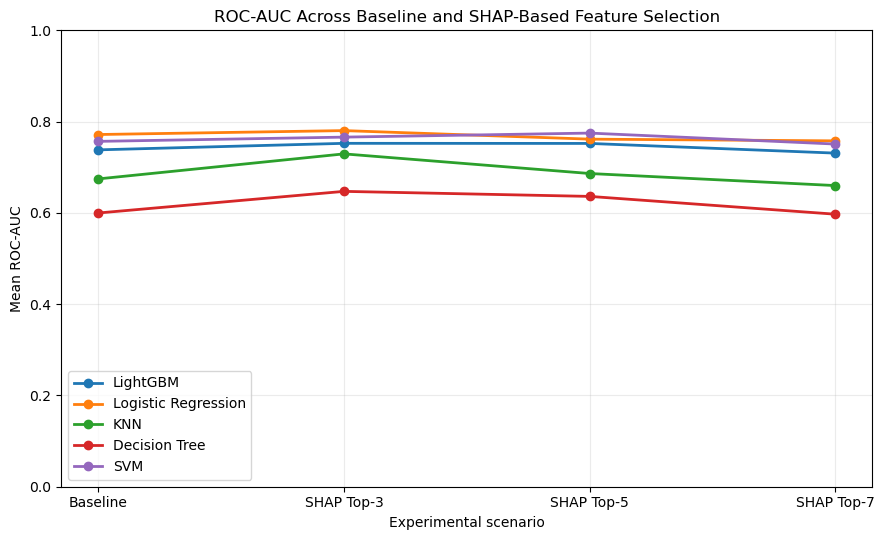

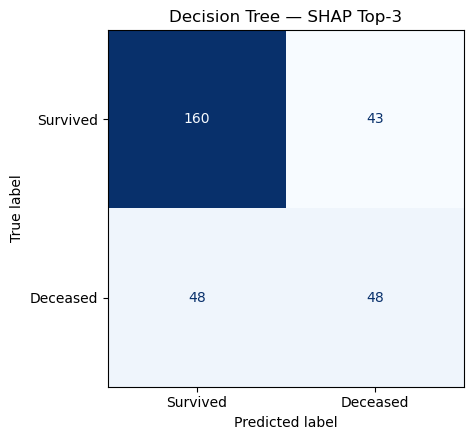

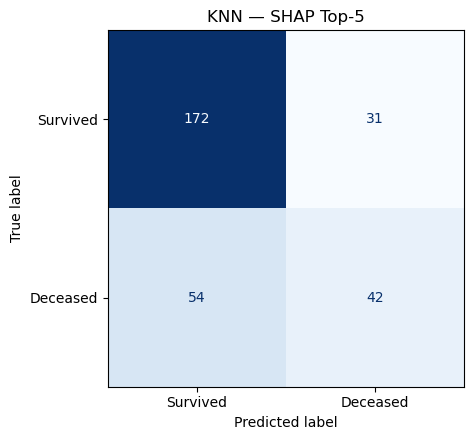

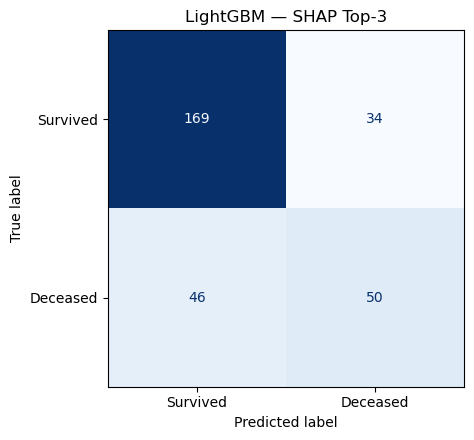

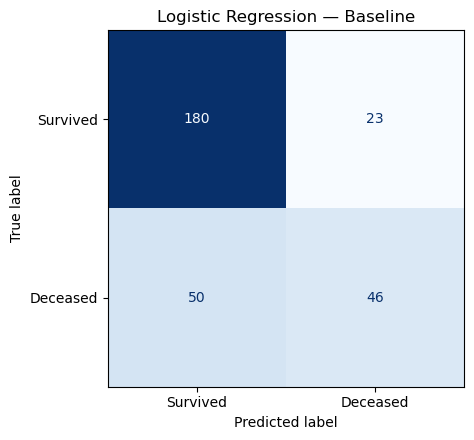

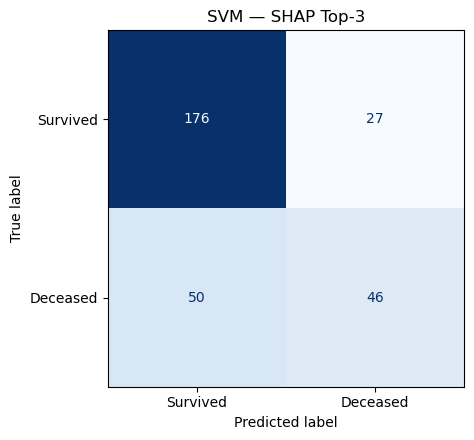

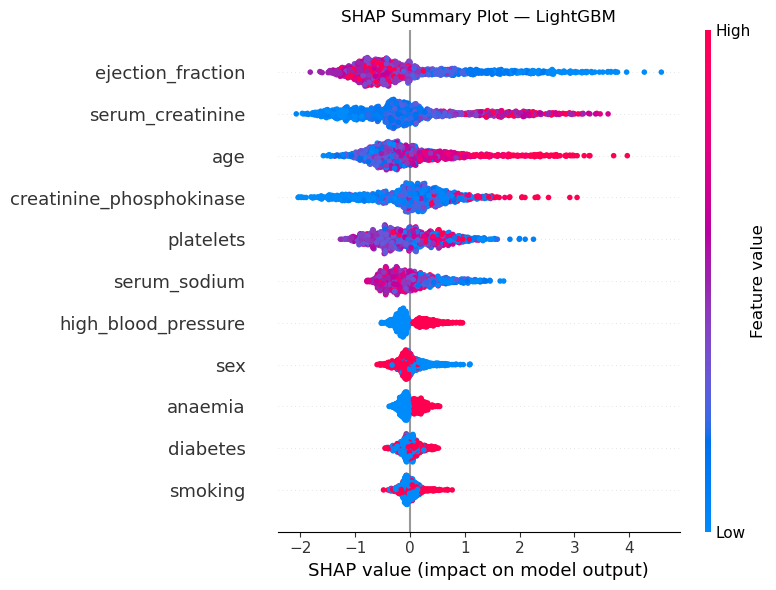

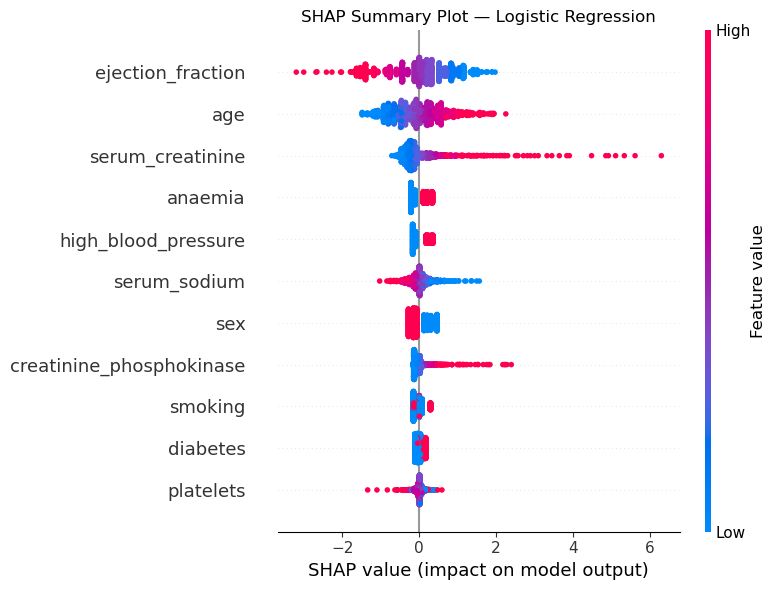

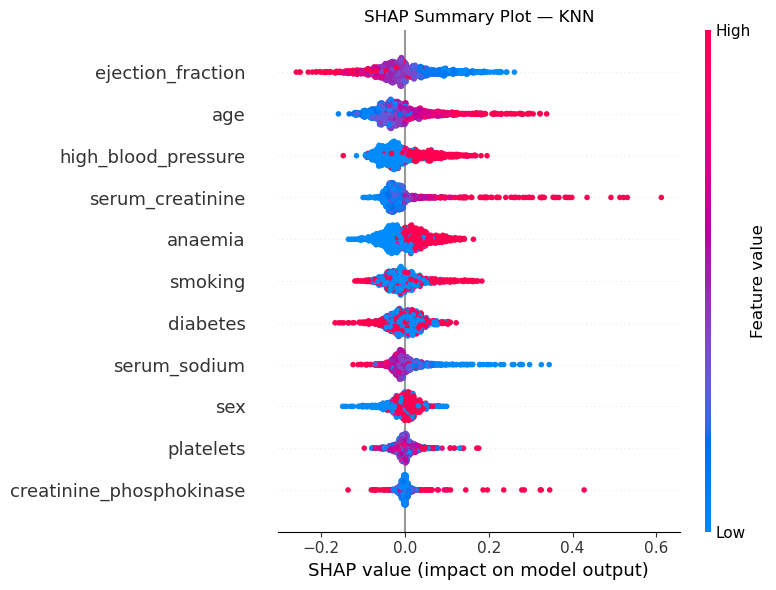

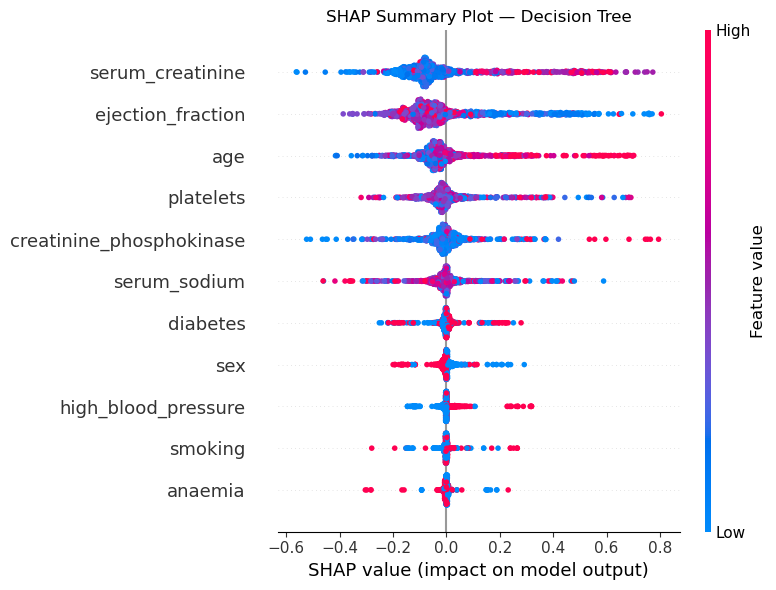

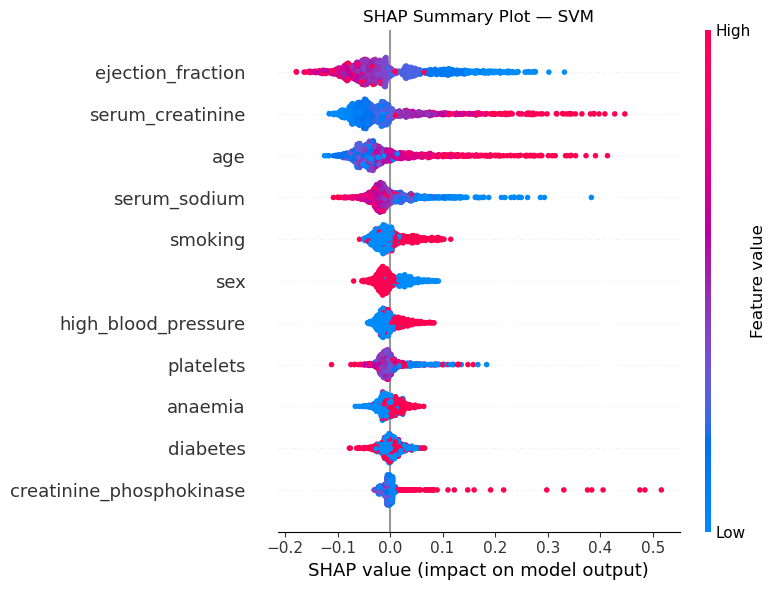

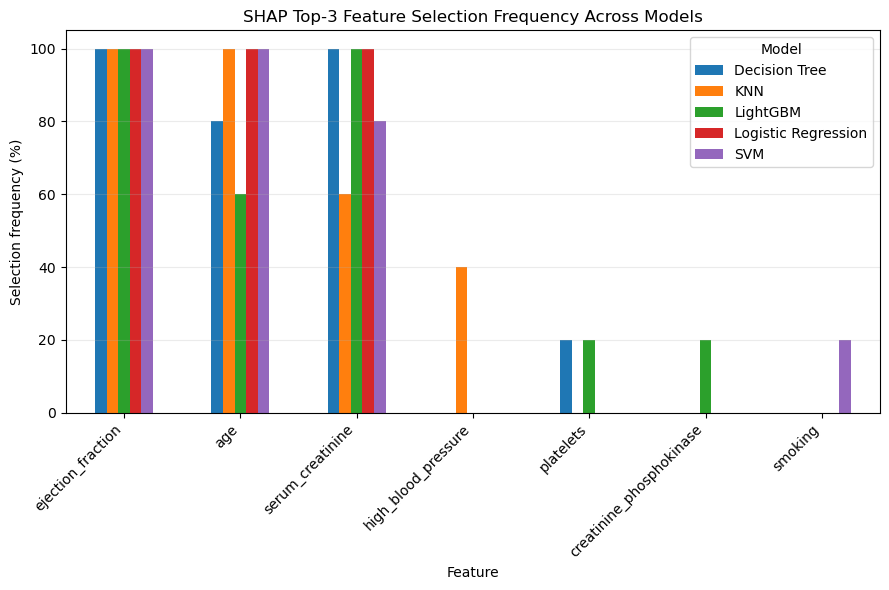

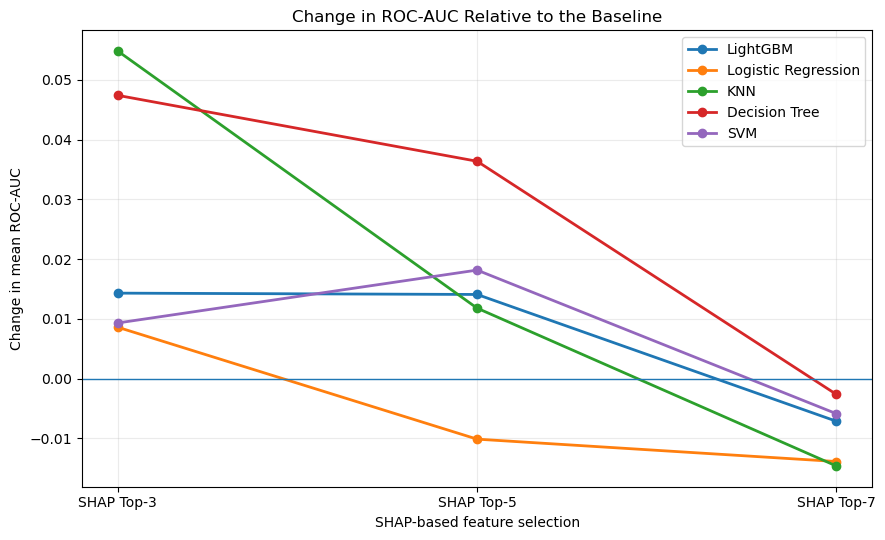


Visualisasi selesai.
Folder gambar: D:\KULIAH\SEMESTER7\SKRIPSI_V3\workspace_model\outputs_shap_final_5models\figures
 - confusion_matrix_decision_tree.png
 - confusion_matrix_knn.png
 - confusion_matrix_lightgbm.png
 - confusion_matrix_logistic_regression.png
 - confusion_matrix_svm.png
 - roc_auc_comparison.png
 - roc_auc_delta_from_baseline.png
 - shap_feature_frequency_top3.png
 - shap_summary_decision_tree.png
 - shap_summary_knn.png
 - shap_summary_lightgbm.png
 - shap_summary_logistic_regression.png
 - shap_summary_svm.png


In [10]:
# ============================================================
# 7. VISUALISASI DAN TABEL UNTUK PAPER
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FIGURE_DIR = Path(CONFIG.output_dir) / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

summary = pd.read_csv(Path(CONFIG.output_dir) / "scenario_summary.csv")
cm = pd.read_csv(Path(CONFIG.output_dir) / "confusion_matrices.csv")
freq = pd.read_csv(Path(CONFIG.output_dir) / "feature_frequency.csv")
shap_feature_ranking = pd.read_csv(
    Path(CONFIG.output_dir) / "shap_feature_ranking.csv"
)
shap_plot_values = pd.read_csv(
    Path(CONFIG.output_dir) / "shap_plot_values.csv"
)
performance_ranking = pd.read_csv(
    Path(CONFIG.output_dir) / "performance_ranking.csv"
)

scenario_order = [
    "BASELINE_ALL",
    "SHAP_TOP3",
    "SHAP_TOP5",
    "SHAP_TOP7",
]

scenario_labels = {
    "BASELINE_ALL": "Baseline",
    "SHAP_TOP3": "SHAP Top-3",
    "SHAP_TOP5": "SHAP Top-5",
    "SHAP_TOP7": "SHAP Top-7",
}

model_order = [
    "LightGBM",
    "Logistic Regression",
    "KNN",
    "Decision Tree",
    "SVM",
]

# ============================================================
# 7.1 TABEL HASIL METRIK LENGKAP
# ============================================================

metric_table_columns = [
    "model",
    "scenario",
    "feature_count",
    "g_mean_mean",
    "mcc_mean",
    "roc_auc_mean",
    "accuracy_mean",
    "precision_mean",
    "sensitivity_recall_mean",
    "specificity_mean",
    "f1_score_mean",
]

metric_table = performance_ranking[metric_table_columns].copy()
metric_table = metric_table.rename(
    columns={
        "g_mean_mean": "G-Mean",
        "mcc_mean": "MCC",
        "roc_auc_mean": "ROC-AUC",
        "accuracy_mean": "Accuracy",
        "precision_mean": "Precision",
        "sensitivity_recall_mean": "Sensitivity/Recall",
        "specificity_mean": "Specificity",
        "f1_score_mean": "F1-Score",
    }
)

print("=" * 110)
print("TABEL METRIK: DIURUTKAN G-MEAN -> MCC -> ROC-AUC -> ACCURACY")
print("=" * 110)
print(metric_table.round(4).to_string(index=False))

metric_table.to_csv(
    Path(CONFIG.output_dir) / "metric_table_for_paper.csv",
    index=False,
)

# ============================================================
# 7.2 ROC-AUC: BASELINE VS SHAP
# ============================================================

plt.figure(figsize=(9, 5.5))

for model in model_order:
    data = summary[summary["model"] == model].copy()
    data["scenario"] = pd.Categorical(
        data["scenario"],
        categories=scenario_order,
        ordered=True,
    )
    data = data.sort_values("scenario")

    plt.plot(
        [scenario_labels[s] for s in data["scenario"].astype(str)],
        data["roc_auc_mean"].to_numpy(),
        marker="o",
        linewidth=2,
        label=model,
    )

plt.xlabel("Experimental scenario")
plt.ylabel("Mean ROC-AUC")
plt.title("ROC-AUC Across Baseline and SHAP-Based Feature Selection")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

roc_path = FIGURE_DIR / "roc_auc_comparison.png"
plt.savefig(roc_path, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 7.3 CONFUSION MATRIX: SKENARIO TERBAIK TIAP MODEL
# ============================================================

# Skenario terbaik ditentukan menggunakan prioritas G-Mean -> MCC -> ROC-AUC -> Accuracy.
best_rows = (
    performance_ranking
    .sort_values("priority_rank")
    .groupby("model", as_index=False)
    .first()
)

for _, best in best_rows.iterrows():
    model = best["model"]
    scenario = best["scenario"]

    row = cm[
        (cm["model"] == model) &
        (cm["scenario"] == scenario)
    ]

    if row.empty:
        continue

    row = row.iloc[0]

    matrix = np.array([
        [int(row["tn"]), int(row["fp"])],
        [int(row["fn"]), int(row["tp"])],
    ])

    fig, ax = plt.subplots(figsize=(5, 4.5))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=["Survived", "Deceased"],
    )
    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        values_format="d",
    )

    ax.set_title(
        f"{model} — {scenario_labels.get(scenario, scenario)}"
    )
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    fig.tight_layout()

    cm_file = FIGURE_DIR / f"confusion_matrix_{safe_model_name(model)}.png"
    fig.savefig(cm_file, dpi=300, bbox_inches="tight")
    plt.show()

# ============================================================
# 7.4 SHAP SUMMARY PLOT PER MODEL
# ============================================================

# Nilai SHAP yang digunakan di sini berasal dari training fold.
# Summary plot digabung dari seluruh fold agar memberikan gambaran global
# mengenai kontribusi fitur pada model, tanpa melibatkan test fold.

for model in model_order:
    model_data = shap_plot_values[
        shap_plot_values["model"] == model
    ].copy()

    if model_data.empty:
        print(f"SHAP summary tidak tersedia untuk {model}.")
        continue

    shap_matrix = (
        model_data
        .pivot_table(
            index=["fold", "sample_index"],
            columns="feature",
            values="shap_value",
            aggfunc="first",
        )
        .fillna(0)
    )

    feature_matrix = (
        model_data
        .pivot_table(
            index=["fold", "sample_index"],
            columns="feature",
            values="feature_value",
            aggfunc="first",
        )
        .reindex(index=shap_matrix.index, columns=shap_matrix.columns)
    )

    # Urutan kolom dibuat berdasarkan mean absolute SHAP agar tabel dan
    # visual konsisten dengan ranking fitur yang disimpan.
    ranking_order = (
        shap_feature_ranking[
            shap_feature_ranking["model"] == model
        ]
        .sort_values("overall_rank")["feature"]
        .tolist()
    )

    ranking_order = [
        feature for feature in ranking_order
        if feature in shap_matrix.columns
    ]

    shap_matrix = shap_matrix[ranking_order]
    feature_matrix = feature_matrix[ranking_order]

    plt.figure()
    shap.summary_plot(
        shap_matrix.to_numpy(),
        feature_matrix.to_numpy(),
        feature_names=ranking_order,
        max_display=len(ranking_order),
        show=False,
        plot_size=(8, 6),
    )

    plt.title(f"SHAP Summary Plot — {model}")
    plt.tight_layout()

    shap_path = FIGURE_DIR / f"shap_summary_{safe_model_name(model)}.png"
    plt.savefig(shap_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

# ============================================================
# 7.5 RANKING DAN KONSISTENSI FITUR SHAP TOP-3
# ============================================================

freq_shap = freq[
    freq["scenario"] == "SHAP_TOP3"
].copy()

if not freq_shap.empty:
    freq_shap["selection_percentage"] = (
        freq_shap["selection_frequency"] * 100
    )

    pivot = freq_shap.pivot_table(
        index="feature",
        columns="model",
        values="selection_percentage",
        aggfunc="max",
        fill_value=0,
    )

    pivot["total"] = pivot.sum(axis=1)
    pivot = (
        pivot
        .sort_values("total", ascending=False)
        .drop(columns="total")
        .head(10)
    )

    ax = pivot.plot(
        kind="bar",
        figsize=(9, 6),
    )
    ax.set_xlabel("Feature")
    ax.set_ylabel("Selection frequency (%)")
    ax.set_title("SHAP Top-3 Feature Selection Frequency Across Models")

    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Model")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()

    feature_path = FIGURE_DIR / "shap_feature_frequency_top3.png"
    plt.savefig(feature_path, dpi=300, bbox_inches="tight")
    plt.show()

# ============================================================
# 7.6 PERUBAHAN ROC-AUC TERHADAP BASELINE
# ============================================================

delta_rows = []

for model in model_order:
    model_data = summary[summary["model"] == model].copy()
    baseline = model_data[
        model_data["scenario"] == "BASELINE_ALL"
    ]

    if baseline.empty:
        continue

    baseline_auc = float(baseline.iloc[0]["roc_auc_mean"])

    for _, row in model_data.iterrows():
        if row["scenario"] == "BASELINE_ALL":
            continue

        delta_rows.append(
            {
                "model": model,
                "scenario": row["scenario"],
                "delta_roc_auc": (
                    float(row["roc_auc_mean"]) - baseline_auc
                ),
            }
        )

delta_df = pd.DataFrame(delta_rows)

if not delta_df.empty:
    plt.figure(figsize=(9, 5.5))

    for model in model_order:
        data = delta_df[delta_df["model"] == model].copy()
        data["scenario"] = pd.Categorical(
            data["scenario"],
            categories=["SHAP_TOP3", "SHAP_TOP5", "SHAP_TOP7"],
            ordered=True,
        )
        data = data.sort_values("scenario")

        plt.plot(
            [scenario_labels[s] for s in data["scenario"].astype(str)],
            data["delta_roc_auc"],
            marker="o",
            linewidth=2,
            label=model,
        )

    plt.axhline(0, linewidth=1)
    plt.xlabel("SHAP-based feature selection")
    plt.ylabel("Change in mean ROC-AUC")
    plt.title("Change in ROC-AUC Relative to the Baseline")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()

    delta_path = FIGURE_DIR / "roc_auc_delta_from_baseline.png"
    plt.savefig(delta_path, dpi=300, bbox_inches="tight")
    plt.show()

print("\nVisualisasi selesai.")
print(f"Folder gambar: {FIGURE_DIR.resolve()}")
for path in sorted(FIGURE_DIR.glob("*.png")):
    print(" -", path.name)


In [9]:
# ============================================================
# 7. JALANKAN EKSPERIMEN FINAL
# ============================================================

results = run_pipeline(CONFIG)


SHAP-BASED FEATURE SELECTION PIPELINE
Dataset       : heart_failure_clinical_records_dataset.csv
Samples       : 299
Features used : 11
Excluded      : time
Target        : death_event
Models        : LightGBM, Logistic Regression, KNN, Decision Tree, SVM
Validation    : Stratified 5-Fold CV
SHAP subsets  : (3, 5, 7)
Class counts  : {0: 203, 1: 96}
SMOTE         : Not used
Prioritas     : G-Mean -> MCC -> ROC-AUC -> Accuracy

Running: LightGBM
  Fold 1/5 complete | baseline AUC=0.6763
  Fold 2/5 complete | baseline AUC=0.7561
  Fold 3/5 complete | baseline AUC=0.6611
  Fold 4/5 complete | baseline AUC=0.8524
  Fold 5/5 complete | baseline AUC=0.7447

Running: Logistic Regression
  Fold 1/5 complete | baseline AUC=0.7025
  Fold 2/5 complete | baseline AUC=0.7471
  Fold 3/5 complete | baseline AUC=0.7535
  Fold 4/5 complete | baseline AUC=0.8357
  Fold 5/5 complete | baseline AUC=0.8197

Running: KNN


PermutationExplainer explainer: 240it [00:28,  7.53it/s]                                                               


  Fold 1/5 complete | baseline AUC=0.7512


PermutationExplainer explainer: 240it [00:19,  5.76it/s]                                                               


  Fold 2/5 complete | baseline AUC=0.7234


...

  Fold 3/5 complete | baseline AUC=0.7542


PermutationExplainer explainer: 240it [00:47,  3.98it/s]                                                               


  Fold 4/5 complete | baseline AUC=0.7997


PermutationExplainer explainer: 241it [00:54,  3.58it/s]                                                               


  Fold 5/5 complete | baseline AUC=0.8368

PIPELINE COMPLETE

RANKING KONFIGURASI BERDASARKAN PRIORITAS
 priority_rank               model     scenario  feature_count  g_mean_mean  mcc_mean  roc_auc_mean  accuracy_mean  f1_score_mean  sensitivity_recall_mean
             1            LightGBM    SHAP_TOP3              3       0.6563    0.3685        0.7524         0.7324         0.5538                   0.5221
             2            LightGBM    SHAP_TOP5              5       0.6560    0.3609        0.7522         0.7225         0.5536                   0.5437
             3            LightGBM    SHAP_TOP7              7       0.6541    0.3675        0.7310         0.7324         0.5502                   0.5226
             4            LightGBM BASELINE_ALL             11       0.6496    0.3693        0.7381         0.7358         0.5478                   0.5016
             5 Logistic Regression BASELINE_ALL             11       0.6492    0.4100        0.7717         0.7560       

## Output hasil eksperimen

Pipeline menghasilkan beberapa file berikut:

- `fold_metrics.csv` — metrik setiap **model × skenario × fold**.
- `scenario_summary.csv` — mean dan standar deviasi dari lima fold serta perubahan terhadap baseline.
- `performance_ranking.csv` — seluruh konfigurasi yang diurutkan berdasarkan **G-Mean → MCC → ROC-AUC → Accuracy**.
- `classification_report_complete.csv` — tabel metrik lengkap mean ± SD.
- `shap_rankings.csv` — ranking SHAP untuk setiap model dan fold.
- `shap_feature_ranking.csv` — ranking SHAP agregat per model dan frekuensi Top-3/5/7.
- `selected_features.csv` — fitur yang dipilih pada setiap fold.
- `feature_frequency.csv` — frekuensi pemilihan fitur antar-fold.
- `confusion_matrices.csv` — agregasi TP/TN/FP/FN.
- `prediction_results.csv` — seluruh prediksi test fold untuk ROC curve.
- `shap_plot_values.csv` — nilai SHAP dan nilai fitur untuk summary plot.
- `metric_table_for_paper.csv` — tabel metrik yang sudah diurutkan berdasarkan prioritas penelitian.
- `SHAP_Heart_Failure_Experiment_Results_Final.xlsx` — seluruh tabel dalam satu workbook.

### Pengendalian data leakage

Test fold hanya digunakan untuk evaluasi akhir pada fold tersebut. Ranking SHAP dan seleksi fitur dilakukan menggunakan training fold saja. StandardScaler untuk model yang memerlukan scaling juga di-*fit* hanya pada training fold.

### Visual tambahan untuk naskah

Visual berikut disiapkan untuk membantu pembahasan hasil:

- **ROC curve** menunjukkan kemampuan diskriminasi berdasarkan prediksi probabilitas/score pada test fold.
- **SHAP summary plot** menunjukkan distribusi kontribusi fitur pada model.
- **Feature selection frequency** menunjukkan seberapa konsisten suatu fitur masuk Top-3 pada lima fold.
- **Confusion matrix** memperlihatkan jumlah prediksi benar dan salah pada konfigurasi terbaik setiap model.

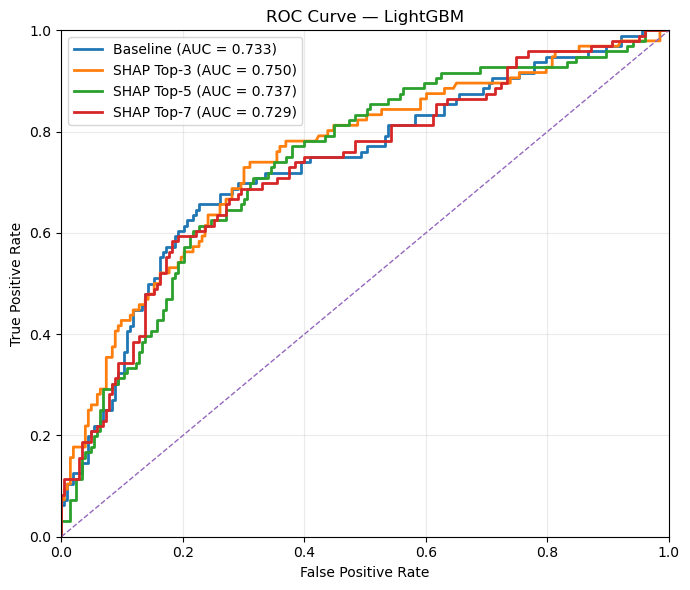

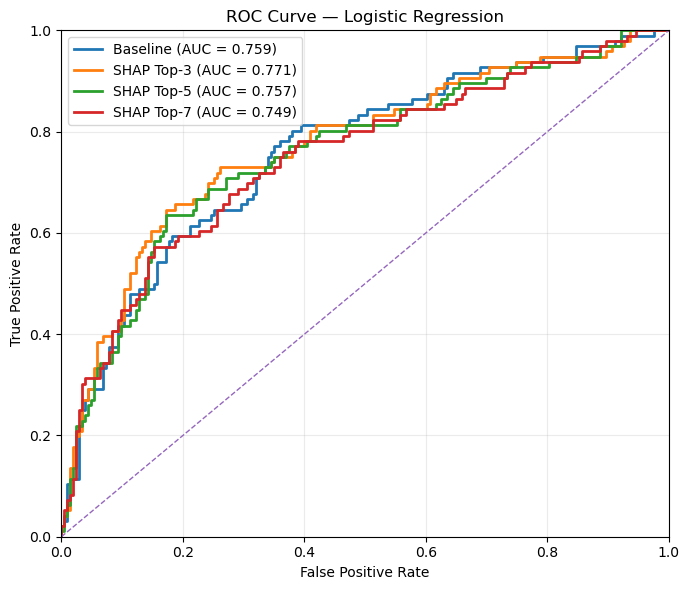

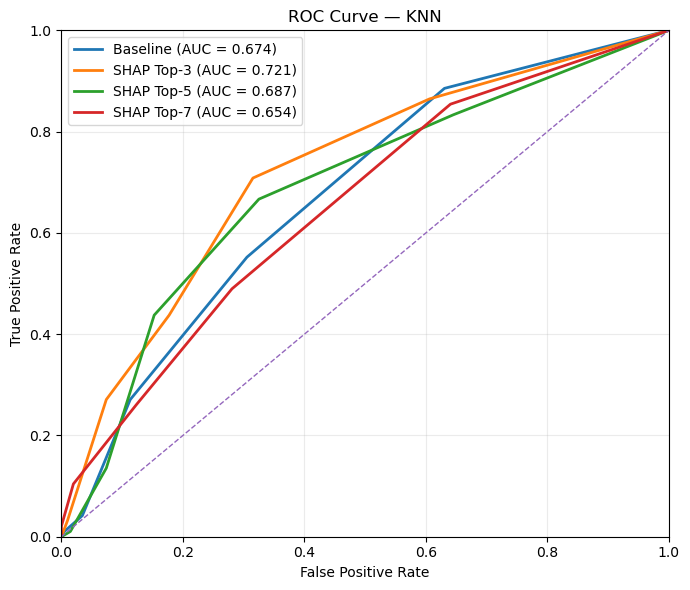

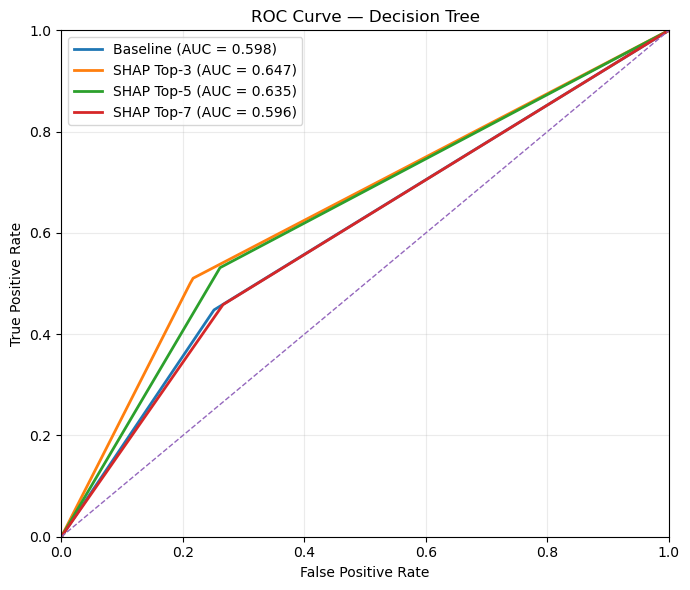

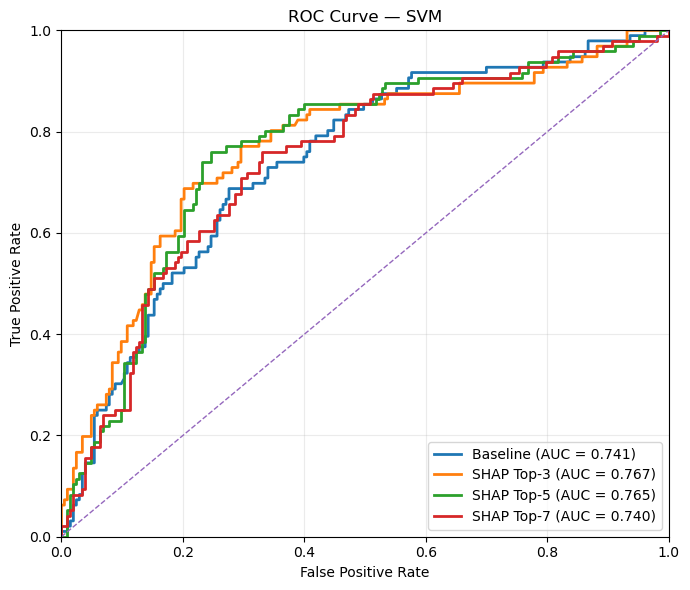

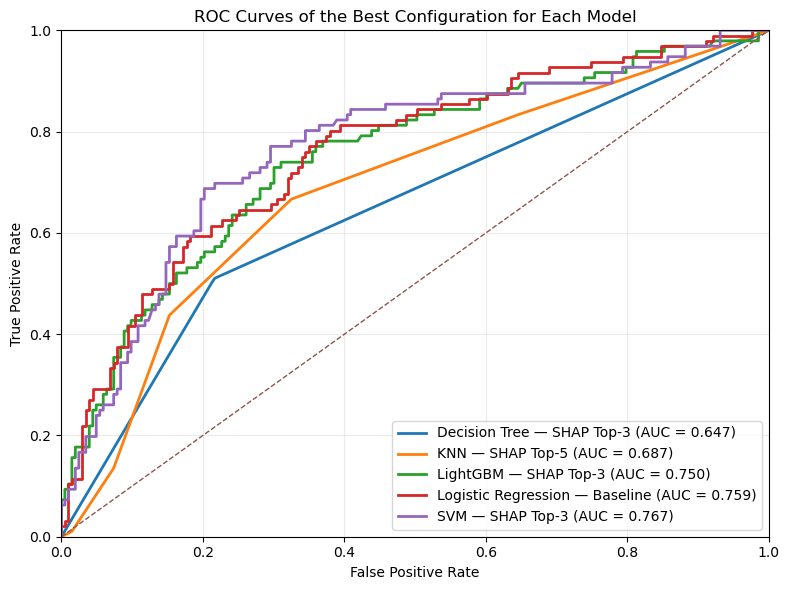


ROC curve berhasil dibuat dari prediksi test fold.


In [11]:
# ============================================================
# 7.5 ROC CURVE DARI PREDIKSI TEST FOLD
# ============================================================

# prediction_results berasal langsung dari test fold pada pipeline utama.
# Tidak ada split, preprocessing, atau training ulang pada bagian ini.
prediction_path = Path(CONFIG.output_dir) / "prediction_results.csv"

if prediction_path.exists():
    prediction_results = pd.read_csv(prediction_path)

    # --------------------------------------------------------
    # ROC curve untuk setiap model pada seluruh skenario.
    # Karena setiap sampel menjadi test fold tepat satu kali dalam
    # Stratified 5-Fold CV, seluruh prediksi dapat digabungkan.
    # --------------------------------------------------------
    for model_name in model_order:
        plt.figure(figsize=(7, 6))

        model_data = prediction_results[
            prediction_results["model"] == model_name
        ]

        for scenario in scenario_order:
            data = model_data[
                model_data["scenario"] == scenario
            ]

            if data.empty:
                continue

            fpr, tpr, _ = roc_curve(
                data["y_true"].astype(int),
                data["y_prob"].astype(float),
            )
            roc_auc = auc(fpr, tpr)

            plt.plot(
                fpr,
                tpr,
                linewidth=2,
                label=(
                    f"{scenario_labels.get(scenario, scenario)} "
                    f"(AUC = {roc_auc:.3f})"
                ),
            )

        plt.plot(
            [0, 1],
            [0, 1],
            linestyle="--",
            linewidth=1,
        )

        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve — {model_name}")
        plt.xlim(0, 1)
        plt.ylim(0, 1)
        plt.legend()
        plt.grid(alpha=0.25)
        plt.tight_layout()

        path = FIGURE_DIR / f"roc_curve_{safe_model_name(model_name)}.png"
        plt.savefig(path, dpi=300, bbox_inches="tight")
        plt.show()

    # --------------------------------------------------------
    # ROC curve gabungan untuk konfigurasi terbaik tiap model.
    # Skenario terbaik mengikuti prioritas G-Mean -> MCC -> ROC-AUC -> Accuracy.
    # --------------------------------------------------------
    best_scenarios = (
        performance_ranking
        .sort_values("priority_rank")
        .groupby("model", as_index=False)
        .first()
    )

    plt.figure(figsize=(8, 6))

    for _, row in best_scenarios.iterrows():
        model_name = row["model"]
        scenario = row["scenario"]

        data = prediction_results[
            (prediction_results["model"] == model_name) &
            (prediction_results["scenario"] == scenario)
        ]

        if data.empty:
            continue

        fpr, tpr, _ = roc_curve(
            data["y_true"].astype(int),
            data["y_prob"].astype(float),
        )
        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            linewidth=2,
            label=(
                f"{model_name} — "
                f"{scenario_labels.get(scenario, scenario)} "
                f"(AUC = {roc_auc:.3f})"
            ),
        )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=1,
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves of the Best Configuration for Each Model")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()

    combined_roc_path = FIGURE_DIR / "roc_curves_best_scenarios.png"
    plt.savefig(
        combined_roc_path,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    print("\nROC curve berhasil dibuat dari prediksi test fold.")
else:
    print(
        "prediction_results.csv belum tersedia. "
        "Jalankan pipeline utama terlebih dahulu."
    )


## Penyimpanan prediksi test dan ROC curve

Prediksi pada setiap test fold disimpan secara eksplisit agar ROC curve dapat dibuat tanpa melakukan split atau pelatihan ulang.

Untuk setiap model, skenario, dan fold, disimpan:
- `y_true`: label aktual pada test fold
- `y_prob`: probabilitas kelas positif
- `y_pred`: hasil klasifikasi dengan threshold 0.5

Dalam Stratified 5-Fold CV, setiap sampel menjadi test sample tepat satu kali. Karena itu, prediksi dari lima fold dapat digabungkan untuk membuat ROC curve berbasis *out-of-fold prediction*.

In [12]:
# ============================================================
# 8. VERIFIKASI PREDIKSI TEST
# ============================================================

# Cell ini hanya membaca hasil prediksi yang telah disimpan oleh pipeline utama.
# Tidak ada split, preprocessing, atau training ulang.
prediction_path = Path(CONFIG.output_dir) / "prediction_results.csv"

if not prediction_path.exists():
    raise FileNotFoundError(
        f"File tidak ditemukan: {prediction_path}. "
        "Jalankan pipeline utama terlebih dahulu."
    )

prediction_results = pd.read_csv(prediction_path)

required_columns = {
    "model",
    "scenario",
    "fold",
    "sample_index",
    "y_true",
    "y_prob",
    "y_pred",
}

missing_columns = required_columns - set(prediction_results.columns)

if missing_columns:
    raise ValueError(
        "Kolom berikut tidak ditemukan pada prediction_results.csv: "
        + ", ".join(sorted(missing_columns))
    )

print("=" * 80)
print("HASIL PREDIKSI TEST")
print("=" * 80)
print(f"Rows       : {len(prediction_results):,}")
print(f"Models     : {prediction_results['model'].nunique()}")
print(f"Scenarios  : {prediction_results['scenario'].nunique()}")
print(f"Folds      : {prediction_results['fold'].nunique()}")

print("\nJumlah baris per model dan skenario:")
print(
    prediction_results
    .groupby(["model", "scenario"])
    .size()
    .to_string()
)

print("\nHasil prediksi tersimpan di:")
print(prediction_path.resolve())


HASIL PREDIKSI TEST
Rows       : 5,980
Models     : 5
Scenarios  : 4
Folds      : 5

Jumlah baris per model dan skenario:
model                scenario    
Decision Tree        BASELINE_ALL    299
                     SHAP_TOP3       299
                     SHAP_TOP5       299
                     SHAP_TOP7       299
KNN                  BASELINE_ALL    299
                     SHAP_TOP3       299
                     SHAP_TOP5       299
                     SHAP_TOP7       299
LightGBM             BASELINE_ALL    299
                     SHAP_TOP3       299
                     SHAP_TOP5       299
                     SHAP_TOP7       299
Logistic Regression  BASELINE_ALL    299
                     SHAP_TOP3       299
                     SHAP_TOP5       299
                     SHAP_TOP7       299
SVM                  BASELINE_ALL    299
                     SHAP_TOP3       299
                     SHAP_TOP5       299
                     SHAP_TOP7       299

Hasil prediksi tersimpa